<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Детекция объектов</b></h3>

В этом домашнем задании мы продолжим работу над детектором из семинара, поэтому при необходимости можете заимствовать оттуда любой код.

Домашнее задание можно разделить на следующие части:

* Переделываем модель [4]
  * Backbone[1],
  * Neck [2],
  * Head [1]
* Label assignment [3]:
  * TAL [3]
* Лоссы [1]:
  * CIoU loss [1]
* Кто больше? [5]
  * 0.05 mAP [1]
  * 0.1 mAP  [2]
  * 0.2 mAP [5]

**Максимальный балл:** 10 баллов. (+3 балла бонус).

In [1]:
import io
import math
from functools import partial

import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import albumentations as A

from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.ops import nms, box_iou, distance_box_iou_loss
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch.transforms import ToTensorV2

### Загрузка данных

Мы продолжаем работу с датасетом из семинара - Halo infinite ([сслыка](https://universe.roboflow.com/graham-doerksen/halo-infinite-angel-aim)). Загрузка данных и создание датасета полностью скопированы из семинара.

Сначала загружаем данные

In [2]:
splits = {'train': 'data/train-00000-of-00001-0d6632d599c29801.parquet',
          'validation': 'data/validation-00000-of-00001-c6b77a557eeedd52.parquet',
          'test': 'data/test-00000-of-00001-866d29d8989ea915.parquet'}
df_train = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["test"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Создаем датасет для предобработки данных

In [27]:
class HaloDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        df_objects = pd.json_normalize(dataframe['objects'])[["bbox", "category"]]
        df_images = pd.json_normalize(dataframe['image'])[["bytes"]]
        self.data = dataframe[["image_id"]].join(df_objects).join(df_images)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """Загружаем данные и разметку для объекта с индексом `idx`.

        labels: List[int] Набор классов для каждого ббокса,
        boxes: List[List[int]] Набор ббоксов в формате (x_min, y_min, w, h).
        """
        row = self.data.iloc[idx]
        image = Image.open(io.BytesIO(row["bytes"]))
        image = np.array(image)

        target = {}
        target["image_id"] = row["image_id"]

        labels = [row["category"]] if isinstance(row["category"], int) else row['category']
        # Вычитаем единицу чтобы классы начинались с нуля
        labels = [label - 1 for label in labels]
        boxes = row['bbox'].tolist()

        if self.transform is not None:
            transformed = self.transform(image=image, bboxes=boxes, labels=labels)
            image, boxes, labels = transformed["image"], transformed["bboxes"], transformed["labels"]
        else:
            image = transforms.ToTensor()(image)

        boxes = torch.tensor(np.array(boxes), dtype=torch.float32)

        # Albumentations возвращает coco: x_min, y_min, width, height
        # Переводим в xyxy: x_min, y_min, x_max, y_max
        if boxes.numel() > 0:
            boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
            boxes[:, 3] = boxes[:, 1] + boxes[:, 3]
        else:
            boxes = boxes.reshape(0, 4)

        target["boxes"] = boxes
        target["labels"] = torch.tensor(labels, dtype=torch.int64)

        return image, target
def collate_fn(batch):
    batch = tuple(zip(*batch))
    images = torch.stack(batch[0])
    return images, batch[1]

Чтобы модель не переобучалась, можно добавить больше аугментаций, весь список можно посмотреть тут [[ссылка](https://explore.albumentations.ai/)].

Какие можно использовать аугментации?
* Добавить зум `RandomResizedCrop`,
* Сделать цветовые аугментации типа `RandomBrightnessContrast` и/или `HueSaturationValue`,
* Добавить шум `GaussNoise`,
* Вырезать случайные части изображения `CoarseDropout`,
* И любые другие!

Аугментации можно комбинировать посредствам `A.OneOf`, `A.SomeOf` или `A.RandomOrder`.

Хоть аугментации ограничиваются только вашей фантазией, перед обучением советуем посмотреть на результат преобразований и убедиться, что изображение ещё поддается детекции:)

In [28]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.Resize(640, 640),
        A.HorizontalFlip(p=0.5),
        A.OneOf(
            [
                A.RandomBrightnessContrast(p=1.0),
                A.HueSaturationValue(p=1.0),
            ],
            p=0.4,
        ),
        A.GaussNoise(p=0.2),
        A.CoarseDropout(
            num_holes_range=(1, 4),
            hole_height_range=(0.05, 0.15),
            hole_width_range=(0.05, 0.15),
            fill=0,
            p=0.2,
        ),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(format='coco', label_fields=['labels'])
)

test_transform = A.Compose(
    [
        A.Resize(640, 640),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["labels"])
)


Не забываем инициализировать наш датасет

In [29]:
train_dataset = HaloDataset(df_train, transform=train_transform)
test_dataset = HaloDataset(df_test, transform=test_transform)

## Переделываем модель [4 балла]

В семинаре мы реализовали самый базовый детектор, а сейчас настало время его улучшать.

### Backbone [1 балл]

Хорошей практикой считается размораживать несколько последних слоев в backbone, это позволяет немного улучить качество модели. Давайте улушчим класс Backbone из лекции, добавив ему возможность разморозки __k__ последних слоев или блоков (на ваш выбор).

In [30]:
class Backbone(nn.Module):
    def __init__(
        self,
        model_name="efficientnet_b0",
        out_indices=(-3, -2, -1),
        pretrained=True,
        unfreeze_last=0,
    ):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=out_indices,
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        if unfreeze_last and unfreeze_last > 0:
            if hasattr(self.backbone, "blocks"):
                trainable_modules = list(self.backbone.blocks.children())[-unfreeze_last:]
            elif hasattr(self.backbone, "stages"):
                trainable_modules = list(self.backbone.stages.children())[-unfreeze_last:]
            else:
                trainable_modules = list(self.backbone.children())[-unfreeze_last:]

            for module in trainable_modules:
                for param in module.parameters():
                    param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

### NECK [2 балла]

Следующее улучшение коснется шеи. Предлагаем реализовать знакомую из лекции архитектуру FPN.

#### Feature Pyramid Network

<center><img src="https://user-images.githubusercontent.com/57972646/69858594-b14a6c00-12d5-11ea-8c3e-3c17063110d3.png"/></center>


* [Feature Pyramid Networks for Object Detection](https://arxiv.org/abs/1612.03144)

Она состоит из top-down пути, в котором происходит 2 вещи:
1. Увеличивается пространственная размерность фичей,
2. С помощью скипконнекшеннов, добавляются фичи из backbone модели.

Для увеличения пространственной размерности используется __nearest neighbor upsampling__, а фичи из шеи и бекбоуна суммируются.

__TIPS__:
* Можете использовать базовые классы из лекции,
* Воспользуйтесь AnchorGenerator-ом, чтобы создавать якоря сразу для нескольких выходов,
* Не забудьте использовать nn.ModuleList, если захотите сделать динамическое количество голов у модели,
* Также, можно добавить доп конволюцию (3х3 с паддингом) у каждого выхода шеи.

In [31]:
class Neck(nn.Module):
    def __init__(self, in_channels, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(ch, out_channels, kernel_size=1) for ch in in_channels
        ])
        self.output_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
            for _ in in_channels
        ])

    def forward(self, features):
        laterals = [conv(feat) for conv, feat in zip(self.lateral_convs, features)]

        for i in range(len(laterals) - 2, -1, -1):
            upsampled = F.interpolate(
                laterals[i + 1],
                size=laterals[i].shape[-2:],
                mode="nearest",
            )
            laterals[i] = laterals[i] + upsampled

        pyramid = [
            conv(lat) for conv, lat in zip(self.output_convs, laterals)
        ]

        return pyramid

### Head [1 балл]

В качестве шеи можно выбрать __один из двух__ вариантов:

#### 1. Decoupled Head

Реализовать Decoupled Head из [YOLOX](https://arxiv.org/abs/2107.08430).
<center><img src="https://i.ibb.co/BVtBR2R3/Decoupled-head.jpg"/></center>

**TIP**: Возьмите за основу голову из семинара, тк она сильно похожа на Decoupled Head.

Изменять количество параметров у шей на разных уровнях не обязательно.

#### 2. Confidence score free head

Нужно взять за основу голову из семинара и полностью убрать предсказание confidence score. Чтобы модель предсказывала только 2 группы: ббоксы и классы.

Есть следующие способы удаления confidence score:
* Добавление нового класса ФОН. Обычно его обозначают нулевым классом.
* Присваивание ббоксам БЕЗ объекта вектор из нулей в качестве таргета.

Выберете тот, который вам больше нравится и будте внимательны при расчете лосса!

**Важно!** Удаление confidence score повлияет на следующие методы из семинара:
* target_assign
* ComputeLoss
* _filter_predictions

In [32]:
class Head(nn.Module):
    def __init__(self, in_channels=256, num_anchors=3, num_classes=4, num_levels=3):
        super().__init__()
        if isinstance(num_anchors, int):
            num_anchors = [num_anchors] * num_levels

        self.num_classes = num_classes
        self.num_levels = num_levels

        self.cls_stems = nn.ModuleList()
        self.reg_stems = nn.ModuleList()
        self.cls_preds = nn.ModuleList()
        self.reg_preds = nn.ModuleList()
        self.obj_preds = nn.ModuleList()

        for anchors_per_level in num_anchors:
            self.cls_stems.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(in_channels),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(in_channels),
                    nn.ReLU(inplace=True),
                )
            )
            self.reg_stems.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(in_channels),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(in_channels),
                    nn.ReLU(inplace=True),
                )
            )
            self.cls_preds.append(nn.Conv2d(in_channels, anchors_per_level * num_classes, kernel_size=1))
            self.reg_preds.append(nn.Conv2d(in_channels, anchors_per_level * 4, kernel_size=1))
            self.obj_preds.append(nn.Conv2d(in_channels, anchors_per_level, kernel_size=1))

    def forward(self, x):
        cls_logits, bbox_offsets, obj_logits = [], [], []
        for level, feat in enumerate(x):
            cls_feat = self.cls_stems[level](feat)
            reg_feat = self.reg_stems[level](feat)

            cls_logits.append(self.cls_preds[level](cls_feat))
            bbox_offsets.append(self.reg_preds[level](reg_feat))
            obj_logits.append(self.obj_preds[level](reg_feat))

        return cls_logits, bbox_offsets, obj_logits

Теперь можно снова реализовать класс детектора с учетом всех частей выше!

In [33]:
class Detector(nn.Module):
    def __init__(
        self,
        backbone_model_name="efficientnet_b0",
        neck_out_channels=256,
        num_classes=4,
        anchor_sizes=((32,), (64,), (128,)),
        anchor_ratios=((0.5, 1.0, 2.0),) * 3,
        input_size=(640, 640),
        out_indices=(-3, -2, -1),
        pretrained=True,
        unfreeze_last=0,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.input_size = input_size

        self.backbone = Backbone(
            model_name=backbone_model_name,
            out_indices=out_indices,
            pretrained=pretrained,
            unfreeze_last=unfreeze_last,
        )

        in_channels = self.backbone.backbone.feature_info.channels()

        self.neck = Neck(
            in_channels=in_channels,
            out_channels=neck_out_channels,
        )

        if isinstance(anchor_sizes[0], (int, float)):
            anchor_sizes = tuple((size,) for size in anchor_sizes)

        if isinstance(anchor_ratios[0], (int, float)):
            anchor_ratios = tuple(tuple(anchor_ratios) for _ in range(len(anchor_sizes)))

        if len(anchor_sizes) != len(in_channels):
            raise ValueError("Количество уровней anchor_sizes должно совпадать с числом выходов backbone.")

        if len(anchor_ratios) != len(in_channels):
            raise ValueError("Количество уровней anchor_ratios должно совпадать с числом выходов backbone.")

        self.num_anchors_per_level = [
            len(sizes) * len(ratios)
            for sizes, ratios in zip(anchor_sizes, anchor_ratios)
        ]

        self.head = Head(
            in_channels=neck_out_channels,
            num_anchors=self.num_anchors_per_level,
            num_classes=num_classes,
            num_levels=len(in_channels),
        )

        reductions = self.backbone.backbone.feature_info.reduction()

        grid_sizes = [
            [input_size[0] // stride, input_size[1] // stride]
            for stride in reductions
        ]

        strides = [
            [stride, stride]
            for stride in reductions
        ]

        anchor_generator = AnchorGenerator(
            sizes=anchor_sizes,
            aspect_ratios=anchor_ratios,
        )

        anchors_per_level = anchor_generator.grid_anchors(grid_sizes, strides)
        anchors = torch.cat(anchors_per_level, dim=0)

        anchor_centers = (anchors[:, :2] + anchors[:, 2:]) / 2
        anchor_sizes_xy = anchors[:, 2:] - anchors[:, :2]

        self.register_buffer("anchors", anchors.unsqueeze(0))
        self.register_buffer("anchor_centers", anchor_centers.unsqueeze(0))
        self.register_buffer("anchor_sizes", anchor_sizes_xy.unsqueeze(0))

    def _flatten_outputs(self, cls_logits, bbox_offsets, obj_logits):
        flat_cls = []
        flat_bbox = []
        flat_obj = []

        for cls_map, box_map, obj_map in zip(cls_logits, bbox_offsets, obj_logits):
            bsz = cls_map.shape[0]

            cls_map = cls_map.permute(0, 2, 3, 1).contiguous()
            cls_map = cls_map.view(bsz, -1, self.num_classes)

            box_map = box_map.permute(0, 2, 3, 1).contiguous()
            box_map = box_map.view(bsz, -1, 4)

            obj_map = obj_map.permute(0, 2, 3, 1).contiguous()
            obj_map = obj_map.view(bsz, -1)

            flat_cls.append(cls_map)
            flat_bbox.append(box_map)
            flat_obj.append(obj_map)

        return (
            torch.cat(flat_bbox, dim=1),
            torch.cat(flat_obj, dim=1),
            torch.cat(flat_cls, dim=1),
        )

    def decode_bboxes(self, bbox_offsets):
        tx = bbox_offsets[..., 0]
        ty = bbox_offsets[..., 1]
        tw = bbox_offsets[..., 2]
        th = bbox_offsets[..., 3]

        center_x = self.anchor_centers[..., 0] + tx * self.anchor_sizes[..., 0]
        center_y = self.anchor_centers[..., 1] + ty * self.anchor_sizes[..., 1]

        w = torch.exp(tw).clamp(max=1e4) * self.anchor_sizes[..., 0]
        h = torch.exp(th).clamp(max=1e4) * self.anchor_sizes[..., 1]

        x_min = center_x - w / 2
        y_min = center_y - h / 2
        x_max = center_x + w / 2
        y_max = center_y + h / 2
        x_min = x_min.clamp(0, self.input_size[1])
        x_max = x_max.clamp(0, self.input_size[1])
        y_min = y_min.clamp(0, self.input_size[0])
        y_max = y_max.clamp(0, self.input_size[0])

        boxes = torch.stack([x_min, y_min, x_max, y_max], dim=-1)

        return boxes

    def forward(self, x):
        features = self.backbone(x)
        pyramid = self.neck(features)

        cls_logits, bbox_offsets, obj_logits = self.head(pyramid)

        bbox_offsets, obj_logits, cls_logits = self._flatten_outputs(
            cls_logits,
            bbox_offsets,
            obj_logits,
        )

        if self.training:
            return bbox_offsets, obj_logits, cls_logits

        boxes = self.decode_bboxes(bbox_offsets)
        objectness = torch.sigmoid(obj_logits)
        cls_probs = torch.softmax(cls_logits, dim=-1)

        return boxes, objectness, cls_probs

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Detector(
    pretrained=True,
    unfreeze_last=2,
).to(device)

x = torch.randn(2, 3, 640, 640).to(device)

model.eval()
with torch.no_grad():
    boxes, conf, cls = model(x)

print("boxes:", boxes.shape)
print("conf:", conf.shape)
print("cls:", cls.shape)

boxes: torch.Size([2, 25200, 4])
conf: torch.Size([2, 25200])
cls: torch.Size([2, 25200, 4])


## Label assignment [3 балла]
В этой секции предлагается заменить функцию `assign_target` на более современный алгоритм который называется Task alignment learning.

Он описан в статье [TOOD](https://arxiv.org/abs/2108.07755) в секции 3.2. Для удобства вот его основные шаги:

1. Посчитать значение метрики для каждого предсказанного ббокса:
    
$$t = s^\alpha * u^\beta$$
    
где,
* $s$ — classification score, или вероятность принадлежности предсказанного ббокса к классу реального ббокса (**GT**);
* $u$ — IoU между предсказанным и реальным ббоксами;
* $\alpha,\ \beta$ — нормализационные константы, обычно $\alpha = 6.0, \ \beta = 1.0$.
    
2. Отфильтровать предсказания на основе **GT**.

    Для якорных детекторов, обычно, выбираются только те предсказания, центры якорей которых находятся внутри GT.
4. Для каждого **GT** выбрать несколько (обычно 5 или 13) самых подходящих предсказаний.
5. Если предсказание рассматривается в качестве подходящего для нескольких **GT** — выбрать **GT** с наибольшим пересечением по IoU.


**BAЖНО**: если будете использовать Runner из лекции, не забудьте поменять параметры  в `self.assign_target_method` в методе `_run_train_epoch`.

In [35]:
def _get_target_offset(anchor_box, gt_box):
    gt_center = (gt_box[:2] + gt_box[2:]) / 2
    gt_size = (gt_box[2:] - gt_box[:2]).clamp_min(1e-6)

    anchor_center = (anchor_box[:2] + anchor_box[2:]) / 2
    anchor_size = (anchor_box[2:] - anchor_box[:2]).clamp_min(1e-6)

    txy = (gt_center - anchor_center) / anchor_size
    twh = torch.log(gt_size / anchor_size)

    return torch.cat([txy, twh], dim=0)


def TAL_assigner(
    anchors,
    pred_boxes,
    pred_cls_logits,
    gt_boxes,
    gt_labels,
    num_classes,
    alpha=6.0,
    beta=1.0,
    topk=13,
):
    device = anchors.device
    num_anchors = anchors.shape[0]

    target_offsets = torch.zeros((num_anchors, 4), device=device)
    target_objectness = torch.zeros((num_anchors,), device=device)
    target_cls = torch.zeros((num_anchors, num_classes), device=device)

    if gt_boxes.numel() == 0:
        return target_offsets, target_objectness, target_cls

    gt_boxes = gt_boxes.to(device)
    gt_labels = gt_labels.to(device).long()

    pred_probs = torch.softmax(pred_cls_logits, dim=-1)

    ious = box_iou(pred_boxes, gt_boxes)

    anchor_centers = (anchors[:, :2] + anchors[:, 2:]) / 2

    inside_gt = (
        (anchor_centers[:, None, 0] >= gt_boxes[None, :, 0]) &
        (anchor_centers[:, None, 0] <= gt_boxes[None, :, 2]) &
        (anchor_centers[:, None, 1] >= gt_boxes[None, :, 1]) &
        (anchor_centers[:, None, 1] <= gt_boxes[None, :, 3])
    )

    cls_scores = pred_probs[:, gt_labels]

    alignment_metric = (cls_scores ** alpha) * (ious ** beta)
    alignment_metric = alignment_metric * inside_gt.float()

    candidate_mask = torch.zeros_like(alignment_metric, dtype=torch.bool)

    for gt_idx in range(gt_boxes.shape[0]):
        metric_for_gt = alignment_metric[:, gt_idx]

        valid = metric_for_gt > 0
        if valid.sum() == 0:
            continue

        k = min(topk, int(valid.sum().item()))
        topk_idx = torch.topk(metric_for_gt, k=k).indices
        candidate_mask[topk_idx, gt_idx] = True

    matched_ious = ious.clone()
    matched_ious[~candidate_mask] = -1

    best_ious, matched_gt_idx = matched_ious.max(dim=1)

    pos_mask = best_ious > 0

    if pos_mask.any():
        matched_gt_boxes = gt_boxes[matched_gt_idx[pos_mask]]
        matched_gt_labels = gt_labels[matched_gt_idx[pos_mask]]

        pos_anchor_indices = torch.where(pos_mask)[0]

        for anchor_idx, gt_box in zip(pos_anchor_indices, matched_gt_boxes):
            target_offsets[anchor_idx] = _get_target_offset(
                anchors[anchor_idx],
                gt_box,
            )

        target_objectness[pos_mask] = 1.0
        target_cls[pos_anchor_indices, matched_gt_labels] = 1.0

    return target_offsets, target_objectness, target_cls

### DIoU [1]

Вместо SmoothL1, который используется в семинаре, реализуем лосс, основанный на пересечении ббоксов. В качестве тренировки давайте напишем Distance Intersection over Union (DIoU).

<center><img src=https://wikidocs.net/images/page/163613/Free_Fig_5.png></center>

Для его реализации разобъем задачу на части:

**1. Реализуем IoU:**

Пусть даны координаты для предсказанного ($B^p$) и истинного ($B^g$) ббоксов в формате XYXY или VOC PASCAL (левый верхний и правый нижний углы):

$B^p=(x^p_1, y^p_1, x^p_2, y^p_2)$, $B^g=(x^g_1, y^g_1, x^g_2, y^g_2)$, тогда алгоритм расчета будет следующий:

    1. Найдем площади обоих ббоксов:
$$ A^p = (x^p_2 - x^p_1) * (y^p_2 - y^p_1) $$
$$ A^g = (x^g_2 - x^g_1) * (y^g_2 - y^g_1) $$

    2. Посчитаем пересечение между ббоксами:

Тут мы предлагаем вам подумать как в общем виде можно расчитать размеры ббокса, который будет являться пересечением $B^p$ и $B^g$, а затем посчитать его площадь:

$$x^I_1 = \max(x^p_1, x^g_1) \qquad \qquad y^I_1 = \max(y^p_1, y^g_1)$$

$$x^I_2 = \min(x^p_2, x^g_2) \qquad \qquad y^I_2 = \min(y^p_2, y^g_2)$$

В общем виде, площать будет записываться следующим образом:

Если $x^I_2 > x^I_1$ & $y^I_2 > y^I_1$, тогда:

$$I = (x^I_2 - x^I_1) * (y^I_2 - y^I_1)$$

Иначе, $I = 0$.

    3. Считаем объединение ббоксов.

Мы можем посчитать эту площадь как сумму площадей двух ббоксов минус площадь пересечения (тк мы считаем её два раз в сумме площадей):

$$U = A^p + A^g - I$$

    4. Вычисляем IoU.

$$IoU = \frac{I}{U}$$

**2. Посчитаем диагональ выпуклой оболочки:**

Для расчета диагонали, сначала выпишите координаты верхнего левого и правого нижнего углов. Подумайте, чему будут равны эти координаты в общем случае?

$$x^c_1 = \min(x^p_1, x^g_1) \qquad \qquad y^c_1 = \min(y^p_1, y^g_1)$$

$$x^c_2 = \max(x^p_2, x^g_2) \qquad \qquad y^c_2 = \max(y^p_2, y^g_2)$$

Подсказка: Нарисуйте несколько вариантов пересечений предсказания и GT на бумажке, и выпишите координаты для выпуклой оболочки.

Тогда квадрат диагонали можно посчитать по формуле:

$$c^2 = (x^c_2 - x^c_1)^2 + (y^c_2 - y^c_1)^2$$

**3. Рассчитаем расстояние между цетрами ббоксов:**

Сначала находим координаты центров каждого из ббоксов (если ббоксы в формате YOLO, то и считать ничего не нужно), затем считаем Евклидово расстояние между центрами.

$$x^p_{center} = \frac{x^p_1 + x^p_2}{2}, \qquad y^p_{center} = \frac{y^p_1 + y^p_2}{2}$$

$$x^g_{center} = \frac{x^g_1 + x^g_2}{2}, \qquad y^g_{center} = \frac{y^g_1 + y^g_2}{2}$$

$$d^2 = (x^p_{center} - x^g_{center})^2 + (y^p_{center} - y^g_{center})^2$$

Собираем все части вместе и считаем лосс по формуле:

$$DIoU = 1 - IoU + \frac{d^2}{c^2}$$

Помните, что пар ббоксов может быть много! Возвращайте усредненное значение лосса.

In [36]:
from torchvision.ops import distance_box_iou_loss

In [37]:
def gen_bbox(num_boxes=10):
    min_corner = torch.randint(0, 100, (num_boxes, 2))
    max_corner = torch.randint(50, 150, (num_boxes, 2))

    for i in range(2):
        wrong_order = min_corner[:, i] > max_corner[:, i]
        if wrong_order.any():
            min_corner[wrong_order, i], max_corner[wrong_order, i] = max_corner[wrong_order, i], min_corner[wrong_order, i]
    return torch.cat((min_corner, max_corner), dim=1)

In [38]:
pred_boxes = gen_bbox(num_boxes=100)
true_boxes = gen_bbox(num_boxes=100)

In [39]:
print(f" DIoU: {distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean").item()}")

 DIoU: 1.011139154434204


In [40]:
def diou_loss(pred_boxes, gt_boxes, eps=1e-7):
    pred_boxes = pred_boxes.float()
    gt_boxes = gt_boxes.float()

    inter_x1 = torch.maximum(pred_boxes[:, 0], gt_boxes[:, 0])
    inter_y1 = torch.maximum(pred_boxes[:, 1], gt_boxes[:, 1])
    inter_x2 = torch.minimum(pred_boxes[:, 2], gt_boxes[:, 2])
    inter_y2 = torch.minimum(pred_boxes[:, 3], gt_boxes[:, 3])

    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter_area = inter_w * inter_h

    pred_area = (pred_boxes[:, 2] - pred_boxes[:, 0]).clamp(min=0) * (pred_boxes[:, 3] - pred_boxes[:, 1]).clamp(min=0)
    gt_area = (gt_boxes[:, 2] - gt_boxes[:, 0]).clamp(min=0) * (gt_boxes[:, 3] - gt_boxes[:, 1]).clamp(min=0)
    union = pred_area + gt_area - inter_area + eps
    iou = inter_area / union

    pred_ctr_x = (pred_boxes[:, 0] + pred_boxes[:, 2]) / 2
    pred_ctr_y = (pred_boxes[:, 1] + pred_boxes[:, 3]) / 2
    gt_ctr_x = (gt_boxes[:, 0] + gt_boxes[:, 2]) / 2
    gt_ctr_y = (gt_boxes[:, 1] + gt_boxes[:, 3]) / 2
    center_dist_sq = (pred_ctr_x - gt_ctr_x).pow(2) + (pred_ctr_y - gt_ctr_y).pow(2)

    enc_x1 = torch.minimum(pred_boxes[:, 0], gt_boxes[:, 0])
    enc_y1 = torch.minimum(pred_boxes[:, 1], gt_boxes[:, 1])
    enc_x2 = torch.maximum(pred_boxes[:, 2], gt_boxes[:, 2])
    enc_y2 = torch.maximum(pred_boxes[:, 3], gt_boxes[:, 3])
    enc_diag_sq = (enc_x2 - enc_x1).pow(2) + (enc_y2 - enc_y1).pow(2) + eps

    loss = 1 - iou + center_dist_sq / enc_diag_sq
    return loss.mean()

In [41]:
import numpy as np
pred_boxes = gen_bbox(num_boxes=1000)
true_boxes = gen_bbox(num_boxes=1000)

# проверим что написанный лосс выдает те же результаты что и лосс из торча.
assert np.isclose(diou_loss(pred_boxes, true_boxes), distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean"))

In [42]:
def decode_offsets_with_anchors(offsets, anchors):
    tx = offsets[:, 0]
    ty = offsets[:, 1]
    tw = offsets[:, 2]
    th = offsets[:, 3]

    anchor_centers = (anchors[:, :2] + anchors[:, 2:]) / 2
    anchor_sizes = (anchors[:, 2:] - anchors[:, :2]).clamp_min(1e-6)

    center_x = anchor_centers[:, 0] + tx * anchor_sizes[:, 0]
    center_y = anchor_centers[:, 1] + ty * anchor_sizes[:, 1]

    w = torch.exp(tw).clamp(max=1e4) * anchor_sizes[:, 0]
    h = torch.exp(th).clamp(max=1e4) * anchor_sizes[:, 1]

    x_min = center_x - w / 2
    y_min = center_y - h / 2
    x_max = center_x + w / 2
    y_max = center_y + h / 2

    return torch.stack([x_min, y_min, x_max, y_max], dim=-1)

In [43]:
class ComputeLoss:
    def __init__(
        self,
        model,
        num_classes=4,
        lambda_box=5.0,
        lambda_obj=1.0,
        lambda_cls=1.0,
        topk=13,
    ):
        self.model = model
        self.num_classes = num_classes
        self.lambda_box = lambda_box
        self.lambda_obj = lambda_obj
        self.lambda_cls = lambda_cls
        self.topk = topk

        self.bce_obj = nn.BCEWithLogitsLoss()
        self.bce_cls = nn.BCEWithLogitsLoss()

    def __call__(self, outputs, targets):
        bbox_offsets, obj_logits, cls_logits = outputs

        device = bbox_offsets.device
        batch_size = bbox_offsets.shape[0]

        anchors = self.model.anchors.squeeze(0).to(device)
        decoded_boxes = self.model.decode_bboxes(bbox_offsets)

        total_box_loss = torch.tensor(0.0, device=device)
        total_obj_loss = torch.tensor(0.0, device=device)
        total_cls_loss = torch.tensor(0.0, device=device)

        for i in range(batch_size):
            gt_boxes = targets[i]["boxes"].to(device)
            gt_labels = targets[i]["labels"].to(device)

            target_offsets, target_objectness, target_cls = TAL_assigner(
                anchors=anchors,
                pred_boxes=decoded_boxes[i].detach(),
                pred_cls_logits=cls_logits[i].detach(),
                gt_boxes=gt_boxes,
                gt_labels=gt_labels,
                num_classes=self.num_classes,
                topk=self.topk,
            )

            pos_mask = target_objectness > 0

            obj_loss = self.bce_obj(obj_logits[i], target_objectness)
            cls_loss = self.bce_cls(cls_logits[i], target_cls)

            if pos_mask.any():
                pred_pos_boxes = decoded_boxes[i][pos_mask]

                target_pos_offsets = target_offsets[pos_mask]
                target_pos_anchors = anchors[pos_mask]
                target_pos_boxes = decode_offsets_with_anchors(
                    target_pos_offsets,
                    target_pos_anchors,
                )
                box_loss = diou_loss(pred_pos_boxes, target_pos_boxes)
            else:
                box_loss = torch.tensor(0.0, device=device)

            total_box_loss += box_loss
            total_obj_loss += obj_loss
            total_cls_loss += cls_loss

        total_box_loss /= batch_size
        total_obj_loss /= batch_size
        total_cls_loss /= batch_size

        total_loss = (
            self.lambda_box * total_box_loss
            + self.lambda_obj * total_obj_loss
            + self.lambda_cls * total_cls_loss
        )

        return total_loss, {
            "box_loss": total_box_loss.item(),
            "obj_loss": total_obj_loss.item(),
            "cls_loss": total_cls_loss.item(),
            "total_loss": total_loss.item(),
        }

## Кто больше? [5 баллов]

Наконец то мы дошли до самый интересной части. Тут мы раздаем очки за mAP'ы!

Все что вы написали выше вам поможет улучшить качество итогового детектора, настало время узнать насколько сильно :)

За достижения порога по mAP на тестовом наборе вы получаете баллы:
* 0.05 mAP [1]
* 0.1 mAP [2]
* 0.2 mAP [5]


**TIPS**:
1. На семинаре мы специально не унифицировали формат ббоксов между методами, чтобы обратить ваше внимание что за этим нужно следить. Чтобы было проще, сразу унифицируете формат по всему ноутбуку. Советуем использовать формат xyxy, тк IoU и NMS из torch используют именно этот формат. (Не забудьте поменять формат у таргета в `HaloDataset`).

2. Попробуйте перейти к IoU-based лоссу при обучении. То есть обучать не смещения, а сразу предсказывать ббокс.

3. Поэксперементируйте с подходами target assignment'а в процессе обучения. Например, можно на первых итерациях использовать обычный метод, а затем подключить TAL.

4. Добавьте аугментаций!

Можно взять [albumentations](https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/), библиотеку, которую мы использовали всеминаре. Или базовые аугментации из торча [тык](https://pytorch.org/vision/main/transforms.html). Если будете использовать торч, не забудте про ббоксы, transforms из коробки не будет их агументировать.

5. Можете реализовать другую шею, которую мы обсуждали на лекции [Path Aggregation Network](https://arxiv.org/abs/1803.01534) она точно улучшит ваше итоговое качество.

6. Попробуйте добавлять различные блоки из YOLO архитектур в шею вместо единичных конволюционных слоев. (Например, замените конволюции 3х3 на CSP блоки).

7. Попробуйте заменить NMS на другой метод (WeightedNMS, SoftNMS, etc.). Немного ссылок:
    * Статья про SoftNMS [тык](https://arxiv.org/pdf/1704.04503)
    * Статья про WeightedNMS [тык](https://openaccess.thecvf.com/content_ICCV_2017_workshops/papers/w14/Zhou_CAD_Scale_Invariant_ICCV_2017_paper.pdf)
    * Есть их реализация, правда на нумбе [git](https://github.com/ZFTurbo/Weighted-Boxes-Fusion?tab=readme-ov-file)

8. Не бойтесь эксперементировать и удачи!

Также, напишите развернутые ответы на следующие вопросы:

**Questions:**
1. Какой метод label assignment'a помогает лучше обучаться модели? Почему?
2. Какое из сделаных вами улучшений внесло наибольший вклад в качество модели? Как вы думаете, почему это произошло?
3. Какое из сделанных вами улучшений вообще не изменило метрику? Как вы думаете, почему это произошло?

1. Лучше обучаться модели помогает Task Alignment Learning assignment. В отличие от простого назначения anchors только по IoU, TAL учитывает не только качество локализации, но и уверенность модели в правильном классе. Поэтому positive anchors выбираются более осмысленно: они должны одновременно хорошо совпадать с объектом и быть полезными для классификации. Это делает обучение более стабильным и помогает модели быстрее фокусироваться на качественных предсказаниях.
2. Наибольший вклад, скорее всего, внесло добавление FPN-neck вместе с использованием признаков с разных уровней backbone. Это важно для object detection, потому что объекты могут иметь разные размеры. FPN позволяет объединять низкоуровневые признаки с хорошей spatial-информацией и высокоуровневые признаки с более сильной семантикой. Благодаря этому модель лучше обнаруживает объекты разного масштаба.
3 Наименьшее влияние на итоговую метрику, вероятно, оказала замена SmoothL1/GIoU-подобного bbox loss на DIoU loss. DIoU делает локализацию более точной за счет штрафа за расстояние между центрами боксов, но если основная проблема модели связана с label assignment, количеством эпох или качеством признаков, то один только новый bbox loss может дать небольшой прирост. Также эффект DIoU может проявляться сильнее при более долгом обучении.

In [44]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)

Ниже определена вспомогательная функция для валидации качества. Можете использовать `Runner.validate`. Важное уточнение, ей нужен метод для фильтрации предсказаний. Можете тоже скопировать его из семинара, если он у вас не менялся.

In [45]:
def filter_predictions(outputs, score_threshold=0.1, nms_threshold=0.5):
    boxes, objectness, cls_probs = outputs

    batch_predictions = []

    for image_boxes, image_objectness, image_cls_probs in zip(boxes, objectness, cls_probs):
        cls_scores, labels = image_cls_probs.max(dim=-1)
        scores = image_objectness * cls_scores

        keep = scores > score_threshold

        image_boxes = image_boxes[keep]
        scores = scores[keep]
        labels = labels[keep]

        if image_boxes.numel() == 0:
            batch_predictions.append({
                "boxes": torch.zeros((0, 4), device=boxes.device),
                "scores": torch.zeros((0,), device=boxes.device),
                "labels": torch.zeros((0,), dtype=torch.long, device=boxes.device),
            })
            continue

        keep_idx = nms(image_boxes, scores, nms_threshold)

        batch_predictions.append({
            "boxes": image_boxes[keep_idx],
            "scores": scores[keep_idx],
            "labels": labels[keep_idx],
        })

    return batch_predictions

In [22]:
!pip install -q "torchmetrics[detection]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.7 MB/s eta 0:00:00


In [46]:
from torchmetrics.detection import MeanAveragePrecision

@torch.no_grad()
def validate(
    model,
    dataloader,
    filter_predictions_func,
    box_format="xyxy",
    device="cpu",
    score_threshold=0.1,
    nms_threshold=0.5,
    **kwargs
):
    model.eval()

    metric = MeanAveragePrecision(box_format=box_format, iou_type="bbox").to(device)

    for images, targets in tqdm(dataloader, desc="Running validation", leave=False):
        images = images.to(device)

        targets = [
            {
                k: v.to(device) if torch.is_tensor(v) else v
                for k, v in target.items()
            }
            for target in targets
        ]

        outputs = model(images)

        predicts = filter_predictions_func(
            outputs,
            score_threshold=score_threshold,
            nms_threshold=nms_threshold,
            **kwargs
        )

        metric.update(predicts, targets)

    result = metric.compute()
    return result["map"].item()


In [47]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()

    logs = {
        "box_loss": 0.0,
        "obj_loss": 0.0,
        "cls_loss": 0.0,
        "total_loss": 0.0,
    }

    for images, targets in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)

        targets = [
            {
                k: v.to(device) if torch.is_tensor(v) else v
                for k, v in target.items()
            }
            for target in targets
        ]

        optimizer.zero_grad()

        outputs = model(images)
        loss, loss_dict = loss_fn(outputs, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        for key in logs:
            logs[key] += loss_dict[key]

    n = len(dataloader)

    return {
        key: value / n
        for key, value in logs.items()
    }

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Detector(
    pretrained=True,
    unfreeze_last=2,
).to(device)

loss_fn = ComputeLoss(
    model=model,
    num_classes=4,
    lambda_box=5.0,
    lambda_obj=1.0,
    lambda_cls=1.0,
    topk=13,
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)

num_epochs = 5

train_losses = []
map_scores = []

for epoch in range(num_epochs):
    train_log = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
    )

    train_losses.append(train_log["total_loss"])

    current_map = validate(
        model=model,
        dataloader=test_loader,
        filter_predictions_func=filter_predictions,
        device=device,
        score_threshold=0.05,
        nms_threshold=0.5,
    )

    map_scores.append(current_map)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"loss={train_log['total_loss']:.4f} | "
        f"box={train_log['box_loss']:.4f} | "
        f"obj={train_log['obj_loss']:.4f} | "
        f"cls={train_log['cls_loss']:.4f} | "
        f"mAP={current_map:.4f}"
    )

Training:   0%|          | 0/116 [00:00<?, ?it/s]

Running validation:   0%|          | 0/34 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db3d51859e0>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7db3d51859e0>    self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    if w.is_alive():self._shutdown_workers()
 
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive(): 
^  ^ ^ ^^  ^ ^^^^^^^^^^^^^^^^
^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

Epoch 1/5 | loss=3.7097 | box=0.5513 | obj=0.4893 | cls=0.4641 | mAP=0.0086


Training:   0%|          | 0/116 [00:00<?, ?it/s]

...

Running validation:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 4/5 | loss=1.8755 | box=0.3533 | obj=0.0705 | cls=0.0382 | mAP=0.0859


Training:   0%|          | 0/116 [00:00<?, ?it/s]

Running validation:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 5/5 | loss=1.7207 | box=0.3294 | obj=0.0502 | cls=0.0233 | mAP=0.1006


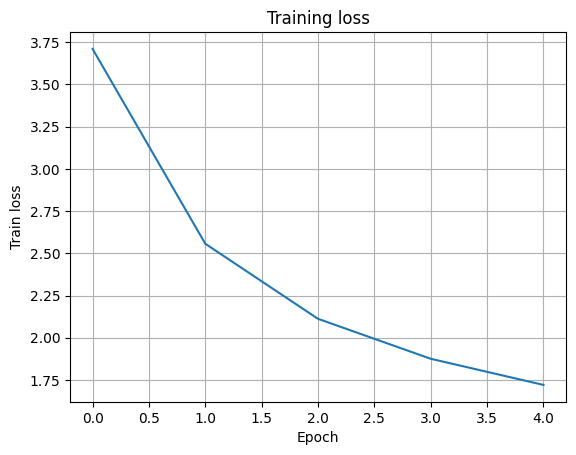

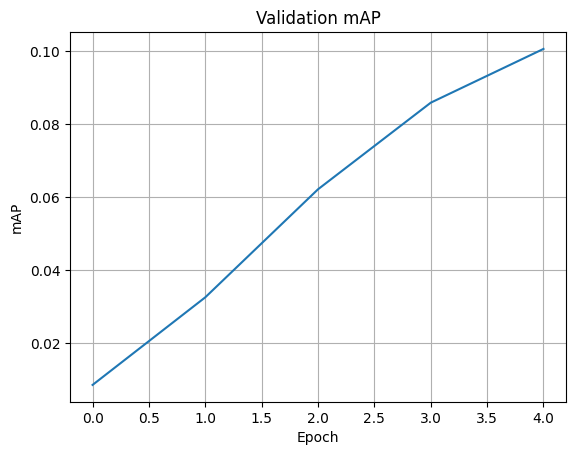

In [49]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training loss")
plt.grid()
plt.show()

plt.figure()
plt.plot(map_scores)
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation mAP")
plt.grid()
plt.show()

In [50]:
results = pd.DataFrame(
    {
        "model": ["EfficientNet-B0 + FPN + Decoupled Head + TAL + DIoU"],
        "input_size": ["640x640"],
        "epochs": [num_epochs],
        "best_mAP": [max(map_scores)],
        "last_mAP": [map_scores[-1]],
    }
)

results

,model,input_size,epochs,best_mAP,last_mAP
0,EfficientNet-B0 + FPN + Decoupled Head + TAL +...,640x640,5,0.100623,0.100623
